In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import GroupKFold
import logging
import sys
from pathlib import Path

# Aggiungi la directory al path
sys.path.insert(0, str(Path.cwd()))

In [31]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Iterable, Optional, Union, Dict, List
import importlib
import Delong_test
importlib.reload(Delong_test)
from Delong_test import delong_test_comparison, p_to_stars, auc_roc_ci
from sklearn.utils import compute_sample_weight


def split_by_center(index, sites: list[str]) -> pd.Series:
    test_folds = pd.Series(index=index, data=[next((site for site in sites if str(idx).lower().startswith(site.lower())), None) for idx in index])
    return test_folds

def eval_model_loco(model_path, train_path, outcome, sites, threshold_months=None):
    """
    outcome: 'DCR' o 'OS_MONTHS'
    threshold_months: se outcome='OS_MONTHS', specifica 6 o 24 per binarizzare
    """
    model = joblib.load(model_path)
    train = pd.read_excel(train_path).set_index('Subject', drop=True)
    
    features = model.feature_names_in_
    
    folds = split_by_center(train.index, sites)
    X = train[features]
    
    y_true = train[outcome]
    
    y_preds = np.zeros(len(y_true))
    
    cv = GroupKFold(n_splits=len(folds.unique()))
    for train_idx, test_idx in cv.split(X, y_true, groups=folds):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y_true.iloc[train_idx])
        model.fit(X.iloc[train_idx], y_true.iloc[train_idx], sample_weight=sample_weight)
        y_preds[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
    
    auc, ci = auc_roc_ci(y_true, y_preds, alpha=0.95)
    std = (ci[1] - ci[0]) / 2
    
    model_name = os.path.basename(model_path).replace('model_', '').replace('.pkl', '')
    
    return auc, std, len(train), model_name

def run_evaluation(base_dir, sites, outcomes, modalities):
    results = []
    
    # Mappa outcome_name → (colonna_excel, threshold)
    outcome_map = {
        'DCR': ('DCR', None),
        'OS_6': ('OS_MONTHS', 6),
        'OS_24': ('OS_MONTHS', 24)
    }

    for outcome_name in outcomes:
        column_name, threshold = outcome_map[outcome_name]
        
        for subset_type in ['all_mods', 'RWD_subset']:
            rwd_subset = (subset_type == 'RWD_subset')

            for modality in modalities:
                pattern = f'{base_dir}/{outcome_name}/{subset_type}/{modality}/model_*.pkl'
                model_files = glob.glob(pattern)
                data_path = f'{base_dir}/{outcome_name}/{subset_type}/{modality}/train_set.xlsx'

                if not model_files:
                    print(f"Warning: no model for {outcome_name}/{subset_type}/{modality}")
                    continue

                model_path = model_files[0]

                auc, std, n_train, model_name = eval_model_loco(
                    model_path, data_path, column_name, sites, threshold
                )

                modality_display = modality.replace('_', ', ')

                results.append({
                    'COHORT': 23,
                    'CV - MODE': 'cross_center',
                    'OUTCOME': outcome_name,
                    'MODALITY': modality_display,
                    'CV AUC': f'{auc:.2f} ± {std:.2f}',
                    'n. test': n_train,
                    'RWD SUBSET': rwd_subset,
                    'features': 'UOC',
                    'MODEL': model_name
                })

    return pd.DataFrame(results)

# Uso:
outcomes = ['DCR', 'OS_24', 'OS_6']
modalities = ['rwd', 'rwd_dp', 'rwd_fmrad', 'rwd_pyrad', 'rwd_dp_fmrad', 'rwd_dp_pyrad']
sites = ['INT', 'GHD', 'VHIO', 'SZMC', 'MH']

df = run_evaluation('/home/ludovica/graphs_notebook/models', sites, outcomes, modalities)
df.to_excel('results.xlsx', index=False)

/home/ludovica/.conda/envs/dann_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ludovica/.conda/envs/dann_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ludovica/.conda/envs/dann_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegre

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Iterable, Optional, Union, Dict, List

def plot_best_auc_by_modality(
    data: Union[str, pd.DataFrame],
    cohort: Optional[Union[int, Iterable[int]]] = None,
    cv_mode: str = "cross_center",
    only_blue: bool = False,
    exclude_modalities: Iterable[str] = ("DP", "FMRAD", "PYRAD"),
    outcome_filter: Optional[Iterable[str]] = None,
    title_prefix: Optional[str] = None,
    min_bubble: float = 30,
    max_bubble: float = 250,
    show: bool = True,
    return_figs: bool = False
) -> Optional[Dict[str, List[plt.Figure]]]:
    """
    Plot AUC comparison across modalities for each outcome.
    
    Parameters
    ----------
    data : str | pd.DataFrame
        Excel path or DataFrame with: COHORT, CV - MODE, OUTCOME, MODALITY, AUC, n. test, RWD SUBSET
    cohort : int | list | None
        Filter by cohort
    cv_mode : str
        'INT' or 'cross_center'
    only_blue : bool
        Show only full multimodal (hide RWD-matched)
    exclude_modalities : list
        Modalities to skip
    outcome_filter : list | None
        Restrict to specific outcomes
    title_prefix : str | None
        Plot title prefix
    min_bubble, max_bubble : float
        Bubble size range
    show : bool
        Display plots
    return_figs : bool
        Return figure objects
    """

    # ═══════════════════════════════════════════════════════════════════
    # HELPERS
    # ═══════════════════════════════════════════════════════════════════
    
    def _ensure_df(d) -> pd.DataFrame:
        """Load Excel or copy DataFrame."""
        return pd.read_excel(d) if isinstance(d, str) else d.copy()

    def _parse_auc(s: Union[str, float]) -> tuple:
        """Parse 'mean ± std' → (mean, std)."""
        if pd.isna(s):
            return (np.nan, np.nan)
        if isinstance(s, (int, float, np.number)):
            return (float(s), 0.0)
        
        parts = [p.strip() for p in str(s).replace("+/-", "±").split("±")]
        if len(parts) == 2:
            try:
                return (float(parts[0]), float(parts[1]))
            except ValueError:
                return (np.nan, np.nan)
        try:
            return (float(parts[0]), 0.0)
        except:
            return (np.nan, np.nan)

    def _scale_sizes(raw_sizes: Iterable) -> np.ndarray:
        """Normalize sizes to [min_bubble, max_bubble]."""
        arr = np.array(list(raw_sizes), dtype=float)
        if len(arr) == 0 or np.all(np.isnan(arr)):
            return np.array([])
        amin, amax = np.nanmin(arr), np.nanmax(arr)
        if amax - amin < 1e-9:
            return np.full_like(arr, (min_bubble + max_bubble) / 2.0)
        norm = (arr - amin) / (amax - amin + 1e-6)
        return norm * (max_bubble - min_bubble) + min_bubble

    def _mod_label(mod: str) -> str:
        """Replace '+' with newline for readability."""
        return str(mod).replace('+', '\n')

    # ═══════════════════════════════════════════════════════════════════
    # LOAD & FILTER
    # ═══════════════════════════════════════════════════════════════════

    df = _ensure_df(data)
    df.columns = df.columns.str.strip()
    
    # Filter cohort
    if cohort is not None:
        if isinstance(cohort, Iterable) and not isinstance(cohort, (str, bytes)):
            df = df[df['COHORT'].isin(list(cohort))]
        else:
            df = df[df['COHORT'] == cohort]

    # Filter CV mode and modalities
    df = df[df["CV - MODE"] == cv_mode]
    if exclude_modalities:
        df = df[~df["MODALITY"].isin(exclude_modalities)]

    # Select outcomes
    if outcome_filter:
        outcomes = [o for o in df["OUTCOME"].unique() if o in set(outcome_filter)]
    else:
        outcomes = df["OUTCOME"].dropna().unique()

    # Set title prefix
    if title_prefix is None:
        title_prefix = "5-CV AUC - INT center" if cv_mode == "INT" else f"AUC - cohort {cohort}" if cohort else "AUC"

    figs_by_outcome = {}

    # ═══════════════════════════════════════════════════════════════════
    # PLOT PER OUTCOME
    # ═══════════════════════════════════════════════════════════════════
    
    for outcome in outcomes:
        print(f"Processing: {outcome}")
        df_out = df[df["OUTCOME"] == outcome]
        if df_out.empty:
            continue

        # Full multimodal (RWD SUBSET == False)
        multi = df_out[df_out["RWD SUBSET"] == False]
        
        multi_auc_means = multi["CV AUC"].apply(lambda x: _parse_auc(x)[0]).astype(float).values
        multi_auc_stds = multi["CV AUC"].apply(lambda x: _parse_auc(x)[1]).astype(float).values
        set_sizes = multi["n. test"].values
        modalities_raw = multi["MODALITY"].astype(str).values
        modalities_lbls = [_mod_label(m) for m in modalities_raw]

        # RWD-matched subset (RWD SUBSET == True)
        sub = df_out[df_out["RWD SUBSET"] == True]
        sub_auc_means = sub["CV AUC"].apply(lambda x: _parse_auc(x)[0]).astype(float).tolist()
        sub_auc_stds = sub["CV AUC"].apply(lambda x: _parse_auc(x)[1]).astype(float).tolist()

        # Carry over RWD-only if present
        if "RWD-only" in modalities_lbls:
            rwd_idx = modalities_lbls.index("RWD-only")
            sub_auc_means.insert(0, float(multi_auc_means[rwd_idx]))
            sub_auc_stds.insert(0, float(multi_auc_stds[rwd_idx]))

        sub_auc_means = np.array(sub_auc_means, dtype=float)
        sub_auc_stds = np.array(sub_auc_stds, dtype=float)

        scaled_sizes = _scale_sizes(set_sizes)

        # ═══════════════════════════════════════════════════════════════
        # PLOTTING
        # ═══════════════════════════════════════════════════════════════
        
        fig = plt.figure(figsize=(12, 6))
        x_pos = np.arange(len(modalities_lbls))

        # Red line (RWD-matched subset)
        if not only_blue and len(sub_auc_means) == len(modalities_lbls):
            plt.plot(x_pos, sub_auc_means, marker='o', linestyle='-', color="#a00000", label='AUC - RWD-only')
            plt.scatter(x_pos, sub_auc_means, s=scaled_sizes, color="#a00000", zorder=3)
            plt.fill_between(x_pos, sub_auc_means - sub_auc_stds, sub_auc_means + sub_auc_stds,
                           color="#d8a6a6", alpha=0.3, label='CI - RWD-only')
            xtick_labels = [f"{m}\n(n. {int(s)})" for m, s in zip(modalities_lbls, set_sizes)]
            plt.xticks(x_pos, xtick_labels)
        else:
            plt.xticks(x_pos, modalities_lbls)

        # Blue line (full multimodal)
        plt.plot(x_pos, multi_auc_means, linestyle='-', color='#1a80bb', label='AUC')
        plt.scatter(x_pos, multi_auc_means, s=scaled_sizes, color='#1a80bb', zorder=3)
        
        std_multiplier = 1  # Amplify CI for visibility
        plt.fill_between(x_pos, 
                        multi_auc_means - multi_auc_stds * std_multiplier,
                        multi_auc_means + multi_auc_stds * std_multiplier,
                        color='#8cc5e3', alpha=0.5, label=f'CI')

        # Text annotations
        multimodal_better = multi_auc_means > sub_auc_means if len(sub_auc_means) == len(multi_auc_means) else [True] * len(multi_auc_means)
        
        for i, (val, std) in enumerate(zip(multi_auc_means, multi_auc_stds)):
            y = 0.06 if (i < len(multimodal_better) and multimodal_better[i] and not only_blue) else 0.02
            plt.text(i, y, f"{val:.2f} ± {std:.2f}", fontsize=10, ha='center', color='#1a80bb')
           
        if not only_blue and len(sub_auc_means) == len(modalities_lbls):
            for i, (val, std) in enumerate(zip(sub_auc_means, sub_auc_stds)):
                y = 0.02 if (i < len(multimodal_better) and multimodal_better[i]) else 0.06
                plt.text(i, y, f"{val:.2f} ± {std:.2f}", fontsize=10, ha='center', color='#a00000')

        # Finalize plot
        plt.title(f"{title_prefix} - {outcome}")
        plt.ylabel("CV AUC")
        plt.ylim(0, 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        
        if show:
            plt.show()
        if return_figs:
            figs_by_outcome.setdefault(outcome, []).append(fig)

    return figs_by_outcome if return_figs else None

Processing: DCR


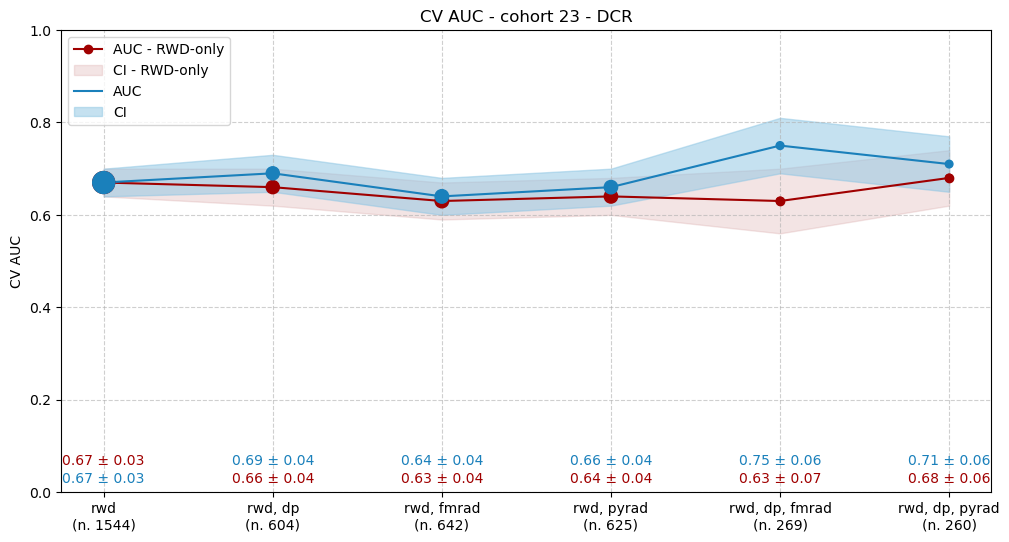

Processing: OS_24


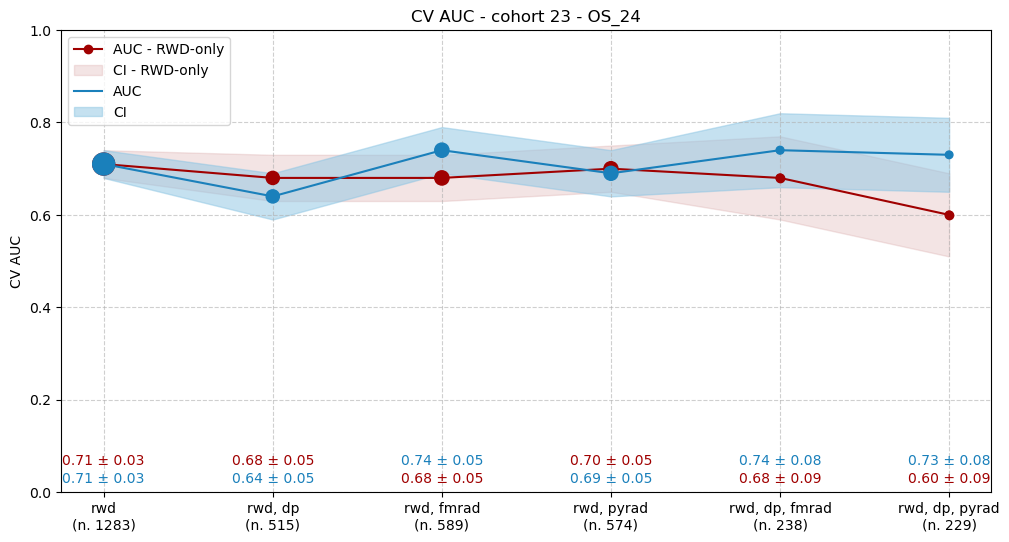

Processing: OS_6


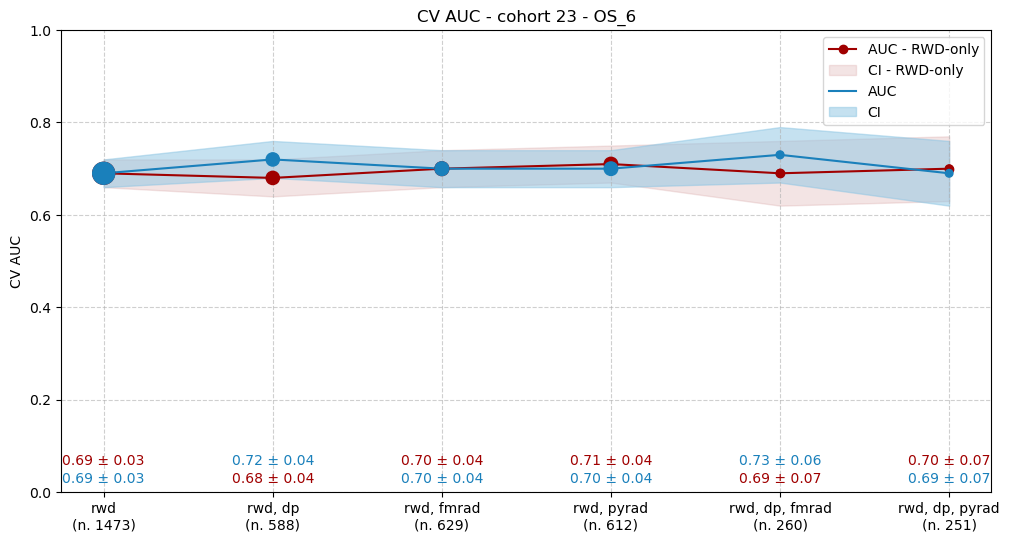

In [32]:
plot_best_auc_by_modality(
    data="results.xlsx",
    cohort=23,
    cv_mode="cross_center",
    only_blue=False,
    title_prefix="CV AUC - cohort 23"
)

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Iterable, Optional, Union, Dict, List
from sklearn.base import clone
from sksurv.util import Surv
from functools import lru_cache
from sklearn.model_selection import GroupKFold
import joblib
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.tree import SurvivalTree
from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, ComponentwiseGradientBoostingSurvivalAnalysis, ExtraSurvivalTrees
import os
from sklearn.model_selection import StratifiedKFold
# ---------- utilities ----------


def bootstrap_pvalue_cindex(event, time, risk1, risk2, n_boot=1000, seed=42) -> float:
    """Two-sided paired bootstrap p-value for C-index difference (risk1 - risk2)."""
    rng = np.random.default_rng(seed)
    event = np.asarray(event, dtype=bool)
    time  = np.asarray(time, dtype=float)
    r1    = np.asarray(risk1, dtype=float)
    r2    = np.asarray(risk2, dtype=float)
    valid = ~np.isnan(r1) & ~np.isnan(r2)
    event, time, r1, r2 = event[valid], time[valid], r1[valid], r2[valid]
    n = len(time)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n, endpoint=False)  # same indices for both models
        c1 = concordance_index_censored(event[idx], time[idx], r1[idx])[0]
        c2 = concordance_index_censored(event[idx], time[idx], r2[idx])[0]
        diffs.append(c1 - c2)
    diffs = np.asarray(diffs)
    return float(np.clip(2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0)), 0.0, 1.0))

def p_to_stars(p: float) -> str:
    if p <= 1e-4: return "****"
    if p <= 1e-3: return "***"
    if p <= 1e-2: return "**"
    if p <= 5e-2: return "*"
    return "ns"

def _predict_risk(model, X) -> np.ndarray:
    """
    Restituisce un vettore 1D di punteggi di rischio per il ranking del C-index.

    Regole:
      - Se è un modello lifelines (es. CoxPHFitter):
            usa predict_partial_hazard() se disponibile,
            altrimenti predict_log_partial_hazard().
      - Altrimenti (modelli scikit-survival): usa predict().

    Ritorna: np.ndarray 1D (float)
    """
    import numpy as np

    # rileva lifelines in modo robusto senza import obbligatorio
    is_lifelines = getattr(model.__class__, "__module__", "").startswith("lifelines")

    if is_lifelines:
        # preferisci il partial hazard (monotono col log-partial-hazard)
        # if hasattr(model, "predict_partial_hazard"):
        #     vals = model.predict_partial_hazard(X)
        #     return np.asarray(vals).ravel()
        if hasattr(model, "predict_log_partial_hazard"):
            vals = model.predict_log_partial_hazard(X)
            return np.asarray(vals).ravel()
        # se per qualche motivo non ci sono i metodi attesi, cade su predict()

    # default per scikit-survival (e altri): usa predict()
    vals = model.predict(X)
    return np.asarray(vals).ravel()


def _fit_survival_model(model, X, event_bool: np.ndarray, time_float: np.ndarray):
    """
    Fit lifelines (CoxPHFitter, etc.) or scikit-survival estimators correctly.
    - lifelines: expects a single DataFrame + names of duration/event columns.
    - scikit-survival: expects (X, y) where y is a structured array from Surv.
    """
    is_lifelines = getattr(model.__class__, "__module__", "").startswith("lifelines")

    if is_lifelines:
        # Build a DataFrame containing covariates + duration/event columns.
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        df["__time__"]  = np.asarray(time_float, dtype=float)
        df["__event__"] = np.asarray(event_bool, dtype=bool).astype(int)

        # Fit lifelines with explicit column names.
        model.fit(df, duration_col="__time__", event_col="__event__")
        return model

    # scikit-survival path
    y = Surv.from_arrays(event=np.asarray(event_bool, dtype=bool),
                         time =np.asarray(time_float, dtype=float))
    model.fit(X, y)
    return model

def _coerce_event_to_bool(series: pd.Series) -> np.ndarray:
    """Map common truthy/falsey representations to bool."""
    s = series
    if s.dtype == bool:
        return s.to_numpy(copy=True)
    if np.issubdtype(s.dtype, np.number):
        return s.astype(int).astype(bool).to_numpy(copy=True)
    # strings like T/F, True/False, 1/0, Y/N, Yes/No
    m = (s.astype(str).str.strip().str.lower()
           .map({'true': True, 't': True, '1': True, 'y': True, 'yes': True,
                 'false': False, 'f': False, '0': False, 'n': False, 'no': False}))
    return m.fillna(False).to_numpy(copy=True)

def get_os_cv_risk_from_neptune(
    run_id: str,
    model_name: str,
    sites: list[str],
    event_col: str,       # <-- use "EVENT"
    time_col: str,        # <-- use "TIME"
    credentials: dict
):
    """
    Reads model from artifacts/model/{model_name} and dataset/train_set (CSV),
    runs LOCO-CV by center, returns (risk, event_bool, time_float).

    If the downloaded train_set lacks the 'Subject' column, recover it from a
    local file at:
        survival_set_for_plot/<cohort>/<outcome>/<modality>/
            INT_SUBSET_<True|False>/RWD_SUBSET_<True|False>/<submodel-join>/train_set.xlsx
    where path components are inferred from Neptune sys/tags:
        subset_int_<T/F>, subset_rwd_<T/F>, cohort_<...>, outcome_<...>,
        datasets_<...>, submodel_<...> (possibly multiple).
    """
    import os
    import glob
    import neptune
    import pandas as pd
    import numpy as np
    from nept_helper import NeptuneHelper
    from sklearn.base import clone

    # ---------- helpers ----------
    def _get_tags(nept_run) -> list[str]:
        try:
            tags = nept_run["sys/tags"].fetch()
            # Neptune may return an object; normalize to a Python list
            if hasattr(tags, "value"):
                tags = tags.value
            if isinstance(tags, (tuple, set)):
                tags = list(tags)
            return list(tags)
        except Exception as e:
            print(f"Warning: failed to fetch sys/tags: {e}")
            return []

    def _tag_value(tags: list[str], prefix: str, default=None):
        # returns the part after 'prefix_' for the first matching tag
        pref = prefix + "_"
        for t in tags:
            if isinstance(t, str) and t.startswith(pref):
                return t[len(pref):]
        return default

    def _tag_multi_values(tags: list[str], prefix: str) -> list[str]:
        # returns all values after 'prefix_' for matching tags (e.g., multiple submodels)
        pref = prefix + "_"
        vals = []
        for t in tags:
            if isinstance(t, str) and t.startswith(pref):
                vals.append(t[len(pref):])
        return vals

    def _normalize_modality_from_tag(datasets_tag_val: str | None) -> str | None:
        """
        Map e.g. 'RWD-DP' -> 'RWD_DP', 'RWD-DP-FMRAD' -> 'RWD_DP_FMRAD'
        """
        if datasets_tag_val is None:
            return None
        # Some tags may include slashes/spaces; normalize harshly
        cleaned = str(datasets_tag_val).strip().replace("/", "-").replace(" ", "")
        return cleaned.replace("-", "_")

    def _find_subject_column_name(df: pd.DataFrame) -> str | None:
        # Common spellings
        candidates = ["Subject", "SUBJECT", "subject", "Subjcet", "SUBJCET", "subjcet"]
        for c in candidates:
            if c in df.columns:
                return c
        # last-resort: case-insensitive exact match for 'subject'
        for c in df.columns:
            if str(c).strip().lower() == "subject":
                return c
        return None

    def _read_local_subject_series_by_tags(tags: list[str]) -> pd.Series | None:
        cohort  = _tag_value(tags, "cohort")
        outcome = _tag_value(tags, "outcome", default="OS")
        modality = _normalize_modality_from_tag(_tag_value(tags, "datasets"))
        # Booleans come as strings 'True'/'False'
        subset_int_str = _tag_value(tags, "subset_int")
        subset_rwd_str = _tag_value(tags, "subset_rwd")
        # Multiple submodels are allowed: submodel_<name> (one or more)
        submodels = _tag_multi_values(tags, "submodel")

        # Fallbacks / coercions
        if cohort is None:
            # very specific to your data; default to COHORT2 if missing
            cohort = "COHORT2"
        if outcome is None:
            outcome = "OS"
        if modality is None:
            # if no datasets tag, try to infer nothing; bail out
            print("No datasets_* tag found; cannot build local path for Subject recovery.")
            return None
        if subset_int_str is None:
            subset_int_str = "False"
        if subset_rwd_str is None:
            subset_rwd_str = "False"
        # join submodels (if none, keep 'ALL' to match a common convention or try wildcards)
        submodels_join = "-".join(submodels) if len(submodels) > 0 else "ALL"

        base_dir = os.path.join(
            '..',
            "survival_set_for_plot",
            cohort,
            outcome,
            modality,
            f"INT_SUBSET_{subset_int_str}",
            f"RWD_SUBSET_{subset_rwd_str}",
            submodels_join
        )

        # try a few filename variants (typo-friendly)
        candidate_files = [
            os.path.join(base_dir, "train_set.xlsx"),
            os.path.join(base_dir, "train_set.xlxs"),  # common typo
            os.path.join(base_dir, "train_set.xls"),
            os.path.join(base_dir, "train_set.csv"),
        ]

        # If directory or file might not match EXACTLY (e.g., different submodel join),
        # try a glob fallback:
        if not any(os.path.isfile(p) for p in candidate_files):
            glob_pattern = os.path.join(
                "survival_set_for_plot",
                cohort,
                outcome,
                modality,
                f"INT_SUBSET_{subset_int_str}",
                f"RWD_SUBSET_{subset_rwd_str}",
                "*",  # any submodel join
                "train_set.*"
            )
            fallback = sorted(glob.glob(glob_pattern))
            candidate_files = fallback + candidate_files  # prefer actual matches if any
            if fallback:
                print(f"Local Subject recovery: using glob match(s): {fallback}")

        # read first existing
        for path in candidate_files:
            try:
                if os.path.isfile(path):
                    if path.lower().endswith(".csv"):
                        df_local = pd.read_csv(path)
                    else:
                        df_local = pd.read_excel(path)
                    subj_col = _find_subject_column_name(df_local)
                    if subj_col is None:
                        print(f"Found local file at {path} but no 'Subject' column.")
                        continue
                    s = df_local[subj_col]
                    # ensure Series name is exactly 'Subject'
                    s = s.rename("Subject")
                    s = s.dropna()
                    print(f"Recovered Subject column from {path} (n={len(s)})")
                    return s
            except Exception as e:
                print(f"Failed reading local file {path}: {e}")

        print("Could not recover Subject column from local files.")
        return None

    # ---------- connect to Neptune ----------
    nept = neptune.init_run(
        project='albertus/I3LUNG',
        api_token=credentials['NEPTUNE_API_TOKEN'],
        with_id=run_id,
        mode='read-only'
    )
    print(f"Connected to Neptune run {run_id}.")

    # ---------- load model (or instantiate from saved hyperparams) ----------
    model = None
    try:
        model = joblib.load(
            NeptuneHelper().download_artifact(
                nept=nept, artifact=f'model/{model_name}', path=None, read=True
            )
        )
        print(f"Loaded model '{model_name}' from Neptune model/{model_name}.")
    except Exception as e:
        print(f"Failed to load model from Neptune model/{model_name}: {e}")
        hyperparameters = nept['parameters/hyperparams'].fetch()
        if not isinstance(hyperparameters, dict):
            try:
                hyperparameters = dict(hyperparameters)
            except Exception:
                pass

        if model_name == 'GB_SURV':
            model = GradientBoostingSurvivalAnalysis(**hyperparameters)
        elif model_name == 'cox_baseline':
            model = CoxPHSurvivalAnalysis(**hyperparameters)
        elif model_name == 'RSF':
            model = RandomSurvivalForest(**hyperparameters)
        elif model_name == 'SURV_TREE':
            model = SurvivalTree(**hyperparameters)
        elif model_name == 'EST':
            model = ExtraSurvivalTrees(**hyperparameters)
        else:
            raise ValueError(f"Unknown model_name: {model_name}")
        print(f"Instantiated {type(model).__name__} with hyperparameters from Neptune.")

    # ---------- load train set from Neptune ----------
    train = pd.read_csv(
        NeptuneHelper().download_artifact(
            nept=nept, artifact='dataset/train_set', path=None, read=True
        )
    )
    print(f"Loaded train set from Neptune dataset/train_set. Columns: {list(train.columns)}")

    # ---------- ensure 'Subject' exists (recover from local if needed) ----------
    if "Subject" not in train.columns:
        print("Neptune train_set has no 'Subject' column; attempting local recovery via sys/tags...")
        tags = _get_tags(nept)
        subj_series = _read_local_subject_series_by_tags(tags)
        if subj_series is not None:
            # Length alignment: prefer one-to-one; otherwise truncate to min length
            n_nept, n_local = len(train), len(subj_series)
            if n_nept != n_local:
                print(f"Warning: Subject length mismatch (neptune={n_nept}, local={n_local}); aligning by position.")
                n = min(n_nept, n_local)
                train = train.iloc[:n].copy()
                subj_series = subj_series.iloc[:n].reset_index(drop=True)
            else:
                subj_series = subj_series.reset_index(drop=True)
            train = train.reset_index(drop=True).copy()
            train.insert(0, "Subject", subj_series)  # add as first column for clarity
            train.drop(columns=['Unnamed: 0'], inplace=True)
            print("Inserted recovered 'Subject' column into train dataframe.")

    # Now we can set index as expected by downstream logic
    train = train.set_index('Subject', drop=True)

    # ---------- labels ----------
    event = _coerce_event_to_bool(train[event_col])
    time  = pd.to_numeric(train[time_col], errors='coerce').astype(float).to_numpy(copy=True)

    # ---------- features ----------
    X_full = train.drop(columns=[event_col, time_col], errors='ignore')
    risk = pd.Series(index=train.index, dtype=float)

    # ---------- 5-fold CV for INT cross val ----------
    if "subset_int_True" in _get_tags(nept):
        print('ok')
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        print("Performing 5-fold Stratified CV by event...")
        for tr_idx, te_idx in cv.split(X_full, event):
            X_tr, X_te = X_full.iloc[tr_idx], X_full.iloc[te_idx]
            e_tr, t_tr = event[tr_idx], time[tr_idx]

            #model = clone(model0)
            _fit_survival_model(model, X_tr, e_tr, t_tr)

            # reference time kept for parity with your original note (not used directly)
            _ = float(np.nanmax(t_tr)) if np.isfinite(np.nanmax(t_tr)) else None

            risk.iloc[te_idx] = _predict_risk(model, X_te)
    else:
    # ---------- LOCO splits by center prefix ----------
        if not sites:
            raise ValueError("`sites` is empty; cannot perform LOCOCV grouping by center.")
        folds = pd.Series(index=train.index, data=[
            next((site for site in sites if str(idx).lower().startswith(site.lower())), None)
            for idx in train.index
        ])
        n_groups = folds.nunique()
        if n_groups < 2:
            raise ValueError(f"Need >=2 site groups for LOCOCV; got {n_groups}. Check `sites`: {sites}")

        cv = GroupKFold(n_splits=n_groups)
        for tr_idx, te_idx in cv.split(X_full, event, groups=folds):
            X_tr, X_te = X_full.iloc[tr_idx], X_full.iloc[te_idx]
            e_tr, t_tr = event[tr_idx], time[tr_idx]

            #model = clone(model0)
            _fit_survival_model(model, X_tr, e_tr, t_tr)

            # reference time kept for parity with your original note (not used directly)
            _ = float(np.nanmax(t_tr)) if np.isfinite(np.nanmax(t_tr)) else None

            risk.iloc[te_idx] = _predict_risk(model, X_te)

    return risk.to_numpy(copy=True), event.astype(bool), time.astype(float)


# ---------- main plotting function (survival) ----------

def plot_best_cindex_by_modality_with_pvalues_survival(
    data: Union[str, pd.DataFrame],
    cohort: Optional[Union[int, Iterable[int]]] = None,
    subset_int: bool = False,                   # matches your INT flag; filters 'SUBSET INT'
    features_required: Optional[str] = "UOC_FEATURES",
    only_blue: bool = False,
    exclude_modalities: Iterable[str] = ("DP", "FMRAD", "PYRAD"),
    modalities_order: Optional[List[str]] = None,  # to impose a custom order if you want
    title_prefix: Optional[str] = None,
    min_bubble: float = 30,
    max_bubble: float = 250,
    sites: Optional[List[str]] = None,          # LOCOCV site prefixes
    # column names in your survival sheet:
    outcome_col: str = "SUBMODEL",
    subset_int_col: str = "SUBSET INT",
    subset_rwd_col: str = "SUBSET RWD",
    metric_col: str = "C-INDEX CV",
    neptune_id_col: str = "NEPTUNE-ID",
    model_name_col: str = "MODEL",
    ntrain_col: str = "n. train",
    features_col: str = "FEATURES",
    # event/time columns inside Neptune's dataset/train_set:
    event_col: str = "OS_EVENT",
    time_col: str = "OS_MONTHS",
    n_boot: int = 1000,
    star_dx: float = 0.18,
    show: bool = True,
    save_path: Optional[str] = None,
    save_figs: bool = False,
    credentials: Optional[dict] = None
) -> Optional[Dict[str, List[plt.Figure]]]:

    def _ensure_df(d) -> pd.DataFrame:
        return d.copy() if isinstance(d, pd.DataFrame) else pd.read_excel(d)

    def _parse_metric(s) -> tuple[float, float]:
        if pd.isna(s): return (np.nan, np.nan)
        if isinstance(s, (int, float, np.number)): return (float(s), 0.0)
        parts = [p.strip() for p in str(s).replace("+/-", "±").split("±")]
        if len(parts) == 2:
            try:    return (float(parts[0]), float(parts[1]))
            except: return (np.nan, np.nan)
        try:        return (float(parts[0]), 0.0)
        except:     return (np.nan, np.nan)

    def _scale_sizes(sizes) -> np.ndarray:
        arr = np.asarray(list(sizes), dtype=float)
        if arr.size == 0 or np.all(np.isnan(arr)): return np.array([])
        amin, amax = np.nanmin(arr), np.nanmax(arr)
        if amax - amin < 1e-9: return np.full_like(arr, (min_bubble + max_bubble)/2.0)
        norm = (arr - amin) / (amax - amin + 1e-6)
        return norm * (max_bubble - min_bubble) + min_bubble

    def _best_rows_per_modality(df_mod: pd.DataFrame) -> pd.DataFrame:
        if df_mod.empty: return df_mod
        means = df_mod[metric_col].apply(lambda x: _parse_metric(x)[0]).astype(float)
        tmp = df_mod.assign(__m__=means)
        idx = tmp.groupby("MODALITY")["__m__"].idxmax()
        best = tmp.loc[idx]
        ordered = df_mod["MODALITY"].drop_duplicates()
        return best.set_index("MODALITY").loc[ordered].reset_index()

    def _order_modalities(df_block: pd.DataFrame) -> pd.DataFrame:
        if not modalities_order:
            return df_block
        order_dict = {m: i for i, m in enumerate(modalities_order)}
        return (df_block.assign(_order=df_block["MODALITY"].map(order_dict).fillna(len(modalities_order)))
                       .sort_values("_order").drop(columns="_order"))

    # cache Neptune pulls
    @lru_cache(maxsize=256)
    def _cached_os_preds(run_id: str, model_name: str):
        return get_os_cv_risk_from_neptune(run_id, model_name, sites or [], event_col, time_col, credentials)

    # ---------- load & filter ----------
    df = _ensure_df(data)
    if modalities_order:
        df = _order_modalities(df)

    if cohort is not None:
        if isinstance(cohort, Iterable) and not isinstance(cohort, (str, bytes)):
            df = df[df["COHORT"].isin(list(cohort))]
        else:
            df = df[df["COHORT"] == cohort]

    if features_required is not None and features_col in df.columns:
        df = df[df[features_col] == features_required]

    df = df[df[subset_int_col] == subset_int]
    if exclude_modalities:
        df = df[~df["MODALITY"].isin(exclude_modalities)]

    outcomes = df[outcome_col].dropna().unique()

    if title_prefix is None:
        title_prefix = ("C-INDEX CV - INT center" if subset_int else (f"C-INDEX CV - cohort {cohort}" if cohort is not None else "C-INDEX CV"))

    figs_by_outcome: Dict[str, List[plt.Figure]] = {}

    # ---------- per outcome ----------
    for outcome in outcomes:
        df_out = df[df[outcome_col] == outcome]
        if df_out.empty: continue

        multi_all = df_out[df_out[subset_rwd_col] == False]
        best_multi = _best_rows_per_modality(multi_all)

        sub_all = df_out[df_out[subset_rwd_col] == True]
        # keep only modalities that appear in multimodal block (like your code)
        sub_all = sub_all[sub_all["MODALITY"].isin(best_multi["MODALITY"].unique())]
        best_sub = _best_rows_per_modality(sub_all)
        sub_by_mod = best_sub.set_index("MODALITY") if not best_sub.empty else pd.DataFrame()

        modalities_raw = best_multi["MODALITY"].astype(str).tolist()
        modalities_lbls = [m.replace('+', '\n') for m in modalities_raw]

        # numbers for plotting
        m_means = best_multi[metric_col].apply(lambda x: _parse_metric(x)[0]).astype(float).to_numpy()
        m_stds  = best_multi[metric_col].apply(lambda x: _parse_metric(x)[1]).astype(float).to_numpy()
        sizes   = best_multi[ntrain_col].to_numpy()
        scaled  = _scale_sizes(sizes)

        # subset series: red starts at RWD (carry over from multi)
        s_means: List[float] = []
        s_stds:  List[float] = []
        if "RWD-only" in modalities_raw:
            ridx = modalities_raw.index("RWD-only")
            s_means.append(float(m_means[ridx]))
            s_stds.append(float(m_stds[ridx]))
        for _, row in best_sub.iterrows():
            mean, std = _parse_metric(row[metric_col])
            s_means.append(float(mean)); s_stds.append(float(std))
        s_means = np.asarray(s_means, dtype=float)
        s_stds  = np.asarray(s_stds, dtype=float)

        # ----- p-values via paired bootstrap (skip RWD) -----
        stars_per_mod = [""] * len(modalities_raw)
        for i, mod in enumerate(modalities_raw):
            if mod == "RWD-only":
                continue
            if sub_by_mod.empty or (mod not in sub_by_mod.index):
                continue
            try:
                # NEPTUNE-ID numeric -> 'IL-<id>'
                raw_multi_id = best_multi.iloc[i][neptune_id_col]
                run_multi = "IL-" + str(int(raw_multi_id))
                raw_sub_id = sub_by_mod.loc[mod][neptune_id_col]
                run_sub = "IL-" + str(int(raw_sub_id))

                model_name_multi = str(best_multi.iloc[i][model_name_col])
                model_name_sub   = str(sub_by_mod.loc[mod][model_name_col])
                print(f'modality: {mod}, model_name_multi: {model_name_multi}, model_name_sub: {model_name_sub}')
                risk_m, event, time = _cached_os_preds(run_multi, model_name_multi)
                print(f'  n (multi) = {len(risk_m)}, events = {np.sum(event)}')
                risk_s, _,    _    = _cached_os_preds(run_sub,   model_name_sub)
                print(f'  n (sub)   = {len(risk_s)}, events = {np.sum(event)}')
                p = bootstrap_pvalue_cindex(event, time, risk_m, risk_s, n_boot=n_boot)
                stars_per_mod[i] = " " + p_to_stars(p)
                print(f'Star for {mod}: {stars_per_mod[i]}')
            except Exception:
                print(f'Failed to get star for {mod}')
                stars_per_mod[i] = ""

        # ---------- plotting ----------
        fig = plt.figure(figsize=(15, 6))
        x_positions = np.arange(0, len(modalities_lbls) * 2, 2)  # step=2 adds space
        if not only_blue and len(s_means) > 0:
            plt.plot(x_positions, s_means, marker='o', linestyle='-', color="#a00000",
                     label='C-INDEX CV - RWD-only matched')
            plt.scatter(x_positions, s_means, s=scaled, color="#a00000", zorder=3)
            plt.fill_between(x_positions, s_means - s_stds, s_means + s_stds,
                             color="#d8a6a6", alpha=0.3, label='Confidence interval - RWD-only matched')
            xtick_labels = [f"{m}\n(n. {int(s)})" for m, s in zip(modalities_lbls, sizes)]
            plt.xticks(x_positions, xtick_labels, rotation=0)
        else:
            plt.xticks(x_positions, modalities_lbls, rotation=0)

        
        plt.plot(x_positions, m_means, linestyle='-', color='#1a80bb', label='C-INDEX CV')
        plt.scatter(x_positions, m_means, s=scaled, color='#1a80bb', zorder=3)
        plt.fill_between(x_positions, m_means - m_stds, m_means + m_stds,
                         color='#8cc5e3', alpha=0.3, label='Confidence interval')

        multimodal_better = None
        if not only_blue and len(s_means) == len(m_means):
            multimodal_better = (m_means > s_means)
        
        # In the plotting section where model names are handled, around the annotation part:

        # blue number + black stars aligned (horizontal shift only)
        for i, (val, std) in enumerate(zip(m_means, m_stds)):
            x = x_positions[i]
            y = 0.06 if (multimodal_better is not None and multimodal_better[i]) and not only_blue else 0.02
            
            # Get model name for multimodal
            model_name_multi = str(best_multi.iloc[i][model_name_col])
            if model_name_multi == 'cox_baseline':
                model_name_multi = 'CoxPH'
            
            txt = f"{val:.2f} ± {std:.2f} ({model_name_multi})"
            plt.text(x, y, txt, fontsize=9, ha='center', color='#1a80bb')
            if stars_per_mod[i]:
                plt.text(x + 0.76, y + 0.006, stars_per_mod[i].strip(), fontsize=10,
                        ha='left', va='center', color='black')

        if not only_blue and len(s_means) == len(m_means):
            for i, (val, std) in enumerate(zip(s_means, s_stds)):
                modality = modalities_raw[i]
                
                # For RWD-only, use the same model name as multimodal
                if modality == "RWD-only":
                    model_name_sub = str(best_multi.iloc[i][model_name_col])
                else:
                    # For other modalities, get from subset models if available
                    if not sub_by_mod.empty and modality in sub_by_mod.index:
                        model_name_sub = sub_by_mod.loc[modality][model_name_col]
                        if isinstance(model_name_sub, pd.Series):
                            model_name_sub = model_name_sub.iloc[0]
                        model_name_sub = str(model_name_sub)
                    else:
                        model_name_sub = "N/A"
                
                if model_name_sub == 'cox_baseline':
                    model_name_sub = 'CoxPH'
                    
                plt.text(x_positions[i], 0.02 if multimodal_better[i] else 0.06,
                        f"{val:.2f} ± {std:.2f} ({model_name_sub})", fontsize=9, ha='center', color='#a00000')
        plt.title(f"{title_prefix} - {outcome}", pad=20)
        plt.ylabel("C-INDEX")
        plt.xlim(-1, x_positions[-1] + 1)
        plt.ylim(0, 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.margins(x=0.20)  # extra room for rightmost stars/text

        if save_figs:
            if not os.path.exists(save_path):
                os.makedirs(save_path)
            plt.savefig(os.path.join(save_path, f"{title_prefix}_{outcome}.png"), dpi=600, bbox_inches='tight')
        if show:
            plt.show()    

    return None


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Iterable, Optional, Union, Dict, List
from functools import lru_cache
from sklearn.model_selection import GroupKFold
import joblib
from sksurv.metrics import concordance_index_censored

def split_by_center(index, sites: list[str]) -> pd.Series:
    return pd.Series(index=index, data=[
        next((site for site in sites if str(idx).lower().startswith(site.lower())), None) 
        for idx in index
    ])

def _predict_risk(model, X) -> np.ndarray:
    is_lifelines = getattr(model.__class__, "__module__", "").startswith("lifelines")
    
    if is_lifelines:
        if hasattr(model, "predict_log_partial_hazard"):
            vals = model.predict_log_partial_hazard(X)
            return np.asarray(vals).ravel()
    
    vals = model.predict(X)
    return np.asarray(vals).ravel()

def _fit_survival_model(model, X, event_bool: np.ndarray, time_float: np.ndarray):
    is_lifelines = getattr(model.__class__, "__module__", "").startswith("lifelines")
    
    if is_lifelines:
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        df["__time__"] = np.asarray(time_float, dtype=float)
        df["__event__"] = np.asarray(event_bool, dtype=bool).astype(int)
        model.fit(df, duration_col="__time__", event_col="__event__")
        return model
    
    from sksurv.util import Surv
    y = Surv.from_arrays(event=np.asarray(event_bool, dtype=bool),
                         time=np.asarray(time_float, dtype=float))
    model.fit(X, y)
    return model

def eval_model_survival(model_path, train_path, time_col, event_col, sites):
    model = joblib.load(model_path)
    train = pd.read_csv(train_path).set_index('Subject', drop=True)
    
    features = [col for col in train.columns if col not in [time_col, event_col, 'fold']]
    
    X = train[features]
    y_time = train[time_col].values.astype(float)
    y_event = train[event_col].astype(bool).values
    
    if y_event.sum() < 2:
        print(f"Error: too few events")
        return np.nan, np.nan, len(train), 'ERROR'
    
    y_preds = np.zeros(len(y_time))
    
    folds = split_by_center(train.index, sites)
    cv = GroupKFold(n_splits=len(folds.unique()))
    
    for train_idx, test_idx in cv.split(X, y_event, groups=folds):
        if y_event[train_idx].sum() < 2:
            print(f"Warning: fold with <2 events, skipping")
            continue
        
        _fit_survival_model(model, X.iloc[train_idx], y_event[train_idx], y_time[train_idx])
        y_preds[test_idx] = _predict_risk(model, X.iloc[test_idx])
    
    if np.all(y_preds == 0):
        print(f"Error: no valid predictions")
        return np.nan, np.nan, len(train), 'ERROR'
    
    # Usa concordance_index_censored invece di concordance_index
    c_index = concordance_index_censored(y_event, y_time, y_preds)[0]
    
    # Bootstrap CI
    n_bootstrap = 1000
    c_indices = []
    rng = np.random.default_rng(42)
    
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_time), size=len(y_time), endpoint=False)
        try:
            c_boot = concordance_index_censored(y_event[idx], y_time[idx], y_preds[idx])[0]
            c_indices.append(c_boot)
        except:
            continue
    
    std = np.std(c_indices) if c_indices else 0.0
    model_name = os.path.basename(model_path).replace('model_', '').replace('.pkl', '')
    
    return c_index, std, len(train), model_name


def run_survival_evaluation(base_dir, sites, modalities):
    results = []
    outcome = 'OS'
    
    for subset_type in ['all_mods', 'RWD_subset']:
        rwd_subset = (subset_type == 'RWD_subset')
        
        for modality in modalities:
            pattern = f'{base_dir}/{outcome}/{subset_type}/{modality}/cox_baseline.pkl'
            model_files = glob.glob(pattern)
            data_path = f'{base_dir}/{outcome}/{subset_type}/{modality}/train_set.csv'
            
            if not model_files:
                print(f"Warning: no model for {outcome}/{subset_type}/{modality}")
                continue
            
            model_path = model_files[0]
            
            c_index, std, n_train, model_name = eval_model_survival(
                model_path, data_path, 'TIME', 'EVENT', sites
            )
            
            modality_display = modality.replace('_', ', ')
            
            results.append({
                'COHORT': 23,
                'SUBMODEL': outcome,
                'MODALITY': modality_display,
                'C-INDEX CV': f'{c_index:.2f} ± {std:.2f}',
                'n. train': n_train,
                'SUBSET INT': False,
                'SUBSET RWD': rwd_subset,
                'FEATURES': 'UOC_FEATURES',
                'MODEL': model_name,
                'NEPTUNE-ID': 0  # non usato per modelli locali
            })
    
    return pd.DataFrame(results)

# Chiama cosi:
modalities = ['rwd', 'rwd_dp', 'rwd_fmrad', 'rwd_pyrad', 'rwd_dp_fmrad', 'rwd_dp_pyrad']
sites = ['INT', 'GHD', 'VHIO', 'SZMC', 'MH']

df_survival = run_survival_evaluation('/home/ludovica/graphs_notebook/models', sites, modalities)
df_survival.to_excel('results_survival.xlsx', index=False)
print(df_survival)

    COHORT SUBMODEL        MODALITY   C-INDEX CV  n. train  SUBSET INT  \
0       23       OS             rwd  0.64 ± 0.01      1549       False   
1       23       OS         rwd, dp  0.59 ± 0.01       604       False   
2       23       OS      rwd, fmrad  0.64 ± 0.01       641       False   
3       23       OS      rwd, pyrad  0.61 ± 0.01       624       False   
4       23       OS  rwd, dp, fmrad  0.67 ± 0.02       268       False   
5       23       OS  rwd, dp, pyrad  0.64 ± 0.02       259       False   
6       23       OS             rwd  0.64 ± 0.01      1549       False   
7       23       OS         rwd, dp  0.64 ± 0.01       604       False   
8       23       OS      rwd, fmrad  0.61 ± 0.01       641       False   
9       23       OS      rwd, pyrad  0.61 ± 0.01       624       False   
10      23       OS  rwd, dp, fmrad  0.60 ± 0.02       268       False   
11      23       OS  rwd, dp, pyrad  0.62 ± 0.02       259       False   

    SUBSET RWD      FEATURES         

In [ ]:
def plot_best_cindex_by_modality_with_pvalues_survival(
    data: Union[str, pd.DataFrame],
    cohort: Optional[Union[int, Iterable[int]]] = None,
    subset_int: bool = False,                   # matches your INT flag; filters 'SUBSET INT'
    features_required: Optional[str] = "UOC_FEATURES",
    only_blue: bool = False,
    exclude_modalities: Iterable[str] = ("DP", "FMRAD", "PYRAD"),
    modalities_order: Optional[List[str]] = None,  # to impose a custom order if you want
    title_prefix: Optional[str] = None,
    min_bubble: float = 30,
    max_bubble: float = 250,
    sites: Optional[List[str]] = None,          # LOCOCV site prefixes
    # column names in your survival sheet:
    outcome_col: str = "SUBMODEL",
    subset_int_col: str = "SUBSET INT",
    subset_rwd_col: str = "SUBSET RWD",
    metric_col: str = "C-INDEX CV",
    neptune_id_col: str = "NEPTUNE-ID",
    model_name_col: str = "MODEL",
    ntrain_col: str = "n. train",
    features_col: str = "FEATURES",
) -> Optional[Dict[str, List[plt.Figure]]]:

    def _ensure_df(d) -> pd.DataFrame:
        return d.copy() if isinstance(d, pd.DataFrame) else pd.read_excel(d)

    def _parse_metric(s) -> tuple[float, float]:
        if pd.isna(s): return (np.nan, np.nan)
        if isinstance(s, (int, float, np.number)): return (float(s), 0.0)
        parts = [p.strip() for p in str(s).replace("+/-", "±").split("±")]
        if len(parts) == 2:
            try:    return (float(parts[0]), float(parts[1]))
            except: return (np.nan, np.nan)
        try:        return (float(parts[0]), 0.0)
        except:     return (np.nan, np.nan)

    def _scale_sizes(sizes) -> np.ndarray:
        arr = np.asarray(list(sizes), dtype=float)
        if arr.size == 0 or np.all(np.isnan(arr)): return np.array([])
        amin, amax = np.nanmin(arr), np.nanmax(arr)
        if amax - amin < 1e-9: return np.full_like(arr, (min_bubble + max_bubble)/2.0)
        norm = (arr - amin) / (amax - amin + 1e-6)
        return norm * (max_bubble - min_bubble) + min_bubble

    def _best_rows_per_modality(df_mod: pd.DataFrame) -> pd.DataFrame:
        if df_mod.empty: return df_mod
        means = df_mod[metric_col].apply(lambda x: _parse_metric(x)[0]).astype(float)
        tmp = df_mod.assign(__m__=means)
        idx = tmp.groupby("MODALITY")["__m__"].idxmax()
        best = tmp.loc[idx]
        ordered = df_mod["MODALITY"].drop_duplicates()
        return best.set_index("MODALITY").loc[ordered].reset_index()

    def _order_modalities(df_block: pd.DataFrame) -> pd.DataFrame:
        if not modalities_order:
            return df_block
        order_dict = {m: i for i, m in enumerate(modalities_order)}
        return (df_block.assign(_order=df_block["MODALITY"].map(order_dict).fillna(len(modalities_order)))
                       .sort_values("_order").drop(columns="_order"))

    # cache Neptune pulls
    @lru_cache(maxsize=256)
    def _cached_os_preds(run_id: str, model_name: str):
        return get_os_cv_risk_from_neptune(run_id, model_name, sites or [], event_col, time_col, credentials)

    # ---------- load & filter ----------
    df = _ensure_df(data)
    if modalities_order:
        df = _order_modalities(df)

    if cohort is not None:
        if isinstance(cohort, Iterable) and not isinstance(cohort, (str, bytes)):
            df = df[df["COHORT"].isin(list(cohort))]
        else:
            df = df[df["COHORT"] == cohort]

    if features_required is not None and features_col in df.columns:
        df = df[df[features_col] == features_required]

    df = df[df[subset_int_col] == subset_int]
    if exclude_modalities:
        df = df[~df["MODALITY"].isin(exclude_modalities)]

    outcomes = df[outcome_col].dropna().unique()

    if title_prefix is None:
        title_prefix = ("C-INDEX CV - INT center" if subset_int else (f"C-INDEX CV - cohort {cohort}" if cohort is not None else "C-INDEX CV"))

    figs_by_outcome: Dict[str, List[plt.Figure]] = {}

    # ---------- per outcome ----------
    for outcome in outcomes:
        df_out = df[df[outcome_col] == outcome]
        if df_out.empty: continue

        multi_all = df_out[df_out[subset_rwd_col] == False]
        best_multi = _best_rows_per_modality(multi_all)

        sub_all = df_out[df_out[subset_rwd_col] == True]
        # keep only modalities that appear in multimodal block (like your code)
        sub_all = sub_all[sub_all["MODALITY"].isin(best_multi["MODALITY"].unique())]
        best_sub = _best_rows_per_modality(sub_all)
        sub_by_mod = best_sub.set_index("MODALITY") if not best_sub.empty else pd.DataFrame()

        modalities_raw = best_multi["MODALITY"].astype(str).tolist()
        modalities_lbls = [m.replace('+', '\n') for m in modalities_raw]

        # numbers for plotting
        m_means = best_multi[metric_col].apply(lambda x: _parse_metric(x)[0]).astype(float).to_numpy()
        m_stds  = best_multi[metric_col].apply(lambda x: _parse_metric(x)[1]).astype(float).to_numpy()
        sizes   = best_multi[ntrain_col].to_numpy()
        scaled  = _scale_sizes(sizes)

        # subset series: red starts at RWD (carry over from multi)
        s_means: List[float] = []
        s_stds:  List[float] = []
        if "RWD-only" in modalities_raw:
            ridx = modalities_raw.index("RWD-only")
            s_means.append(float(m_means[ridx]))
            s_stds.append(float(m_stds[ridx]))
        for _, row in best_sub.iterrows():
            mean, std = _parse_metric(row[metric_col])
            s_means.append(float(mean)); s_stds.append(float(std))
        s_means = np.asarray(s_means, dtype=float)
        s_stds  = np.asarray(s_stds, dtype=float)

        # ----- p-values via paired bootstrap (skip RWD) -----
        stars_per_mod = [""] * len(modalities_raw)
        for i, mod in enumerate(modalities_raw):
            if mod == "RWD-only":
                continue
            if sub_by_mod.empty or (mod not in sub_by_mod.index):
                continue
            try:
                # NEPTUNE-ID numeric -> 'IL-<id>'
                raw_multi_id = best_multi.iloc[i][neptune_id_col]
                run_multi = "IL-" + str(int(raw_multi_id))
                raw_sub_id = sub_by_mod.loc[mod][neptune_id_col]
                run_sub = "IL-" + str(int(raw_sub_id))

                model_name_multi = str(best_multi.iloc[i][model_name_col])
                model_name_sub   = str(sub_by_mod.loc[mod][model_name_col])
                print(f'modality: {mod}, model_name_multi: {model_name_multi}, model_name_sub: {model_name_sub}')
                risk_m, event, time = _cached_os_preds(run_multi, model_name_multi)
                print(f'  n (multi) = {len(risk_m)}, events = {np.sum(event)}')
                risk_s, _,    _    = _cached_os_preds(run_sub,   model_name_sub)
                print(f'  n (sub)   = {len(risk_s)}, events = {np.sum(event)}')
                p = bootstrap_pvalue_cindex(event, time, risk_m, risk_s, n_boot=n_boot)
                stars_per_mod[i] = " " + p_to_stars(p)
                print(f'Star for {mod}: {stars_per_mod[i]}')
            except Exception:
                print(f'Failed to get star for {mod}')
                stars_per_mod[i] = ""

        # ---------- plotting ----------
        fig = plt.figure(figsize=(15, 6))
        x_positions = np.arange(0, len(modalities_lbls) * 2, 2)  # step=2 adds space
        if not only_blue and len(s_means) > 0:
            plt.plot(x_positions, s_means, marker='o', linestyle='-', color="#a00000",
                     label='C-INDEX CV - RWD-only matched')
            plt.scatter(x_positions, s_means, s=scaled, color="#a00000", zorder=3)
            plt.fill_between(x_positions, s_means - s_stds, s_means + s_stds,
                             color="#d8a6a6", alpha=0.3, label='Confidence interval - RWD-only matched')
            xtick_labels = [f"{m}\n(n. {int(s)})" for m, s in zip(modalities_lbls, sizes)]
            plt.xticks(x_positions, xtick_labels, rotation=0)
        else:
            plt.xticks(x_positions, modalities_lbls, rotation=0)

        
        plt.plot(x_positions, m_means, linestyle='-', color='#1a80bb', label='C-INDEX CV')
        plt.scatter(x_positions, m_means, s=scaled, color='#1a80bb', zorder=3)
        plt.fill_between(x_positions, m_means - m_stds, m_means + m_stds,
                         color='#8cc5e3', alpha=0.3, label='Confidence interval')

        multimodal_better = None
        if not only_blue and len(s_means) == len(m_means):
            multimodal_better = (m_means > s_means)
        
        # In the plotting section where model names are handled, around the annotation part:

        # blue number + black stars aligned (horizontal shift only)
        for i, (val, std) in enumerate(zip(m_means, m_stds)):
            x = x_positions[i]
            y = 0.06 if (multimodal_better is not None and multimodal_better[i]) and not only_blue else 0.02
            
            # Get model name for multimodal
            model_name_multi = str(best_multi.iloc[i][model_name_col])
            if model_name_multi == 'cox_baseline':
                model_name_multi = 'CoxPH'
            
            txt = f"{val:.2f} ± {std:.2f} ({model_name_multi})"
            plt.text(x, y, txt, fontsize=9, ha='center', color='#1a80bb')
            if stars_per_mod[i]:
                plt.text(x + 0.76, y + 0.006, stars_per_mod[i].strip(), fontsize=10,
                        ha='left', va='center', color='black')

        if not only_blue and len(s_means) == len(m_means):
            for i, (val, std) in enumerate(zip(s_means, s_stds)):
                modality = modalities_raw[i]
                
                # For RWD-only, use the same model name as multimodal
                if modality == "RWD-only":
                    model_name_sub = str(best_multi.iloc[i][model_name_col])
                else:
                    # For other modalities, get from subset models if available
                    if not sub_by_mod.empty and modality in sub_by_mod.index:
                        model_name_sub = sub_by_mod.loc[modality][model_name_col]
                        if isinstance(model_name_sub, pd.Series):
                            model_name_sub = model_name_sub.iloc[0]
                        model_name_sub = str(model_name_sub)
                    else:
                        model_name_sub = "N/A"
                
                if model_name_sub == 'cox_baseline':
                    model_name_sub = 'CoxPH'
                    
                plt.text(x_positions[i], 0.02 if multimodal_better[i] else 0.06,
                        f"{val:.2f} ± {std:.2f} ({model_name_sub})", fontsize=9, ha='center', color='#a00000')
        plt.title(f"{title_prefix} - {outcome}", pad=20)
        plt.ylabel("C-INDEX")
        plt.xlim(-1, x_positions[-1] + 1)
        plt.ylim(0, 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.margins(x=0.20)  # extra room for rightmost stars/text

        if save_figs:
            if not os.path.exists(save_path):
                os.makedirs(save_path)
            plt.savefig(os.path.join(save_path, f"{title_prefix}_{outcome}.png"), dpi=600, bbox_inches='tight')
        if show:
            plt.show()    

    return None


modality: rwd, model_name_multi: cox_baseline, model_name_sub: cox_baseline
Failed to get star for rwd
modality: rwd, dp, model_name_multi: cox_baseline, model_name_sub: cox_baseline
Failed to get star for rwd, dp
modality: rwd, fmrad, model_name_multi: cox_baseline, model_name_sub: cox_baseline
Failed to get star for rwd, fmrad
modality: rwd, pyrad, model_name_multi: cox_baseline, model_name_sub: cox_baseline
Failed to get star for rwd, pyrad
modality: rwd, dp, fmrad, model_name_multi: cox_baseline, model_name_sub: cox_baseline
Failed to get star for rwd, dp, fmrad
modality: rwd, dp, pyrad, model_name_multi: cox_baseline, model_name_sub: cox_baseline
Failed to get star for rwd, dp, pyrad


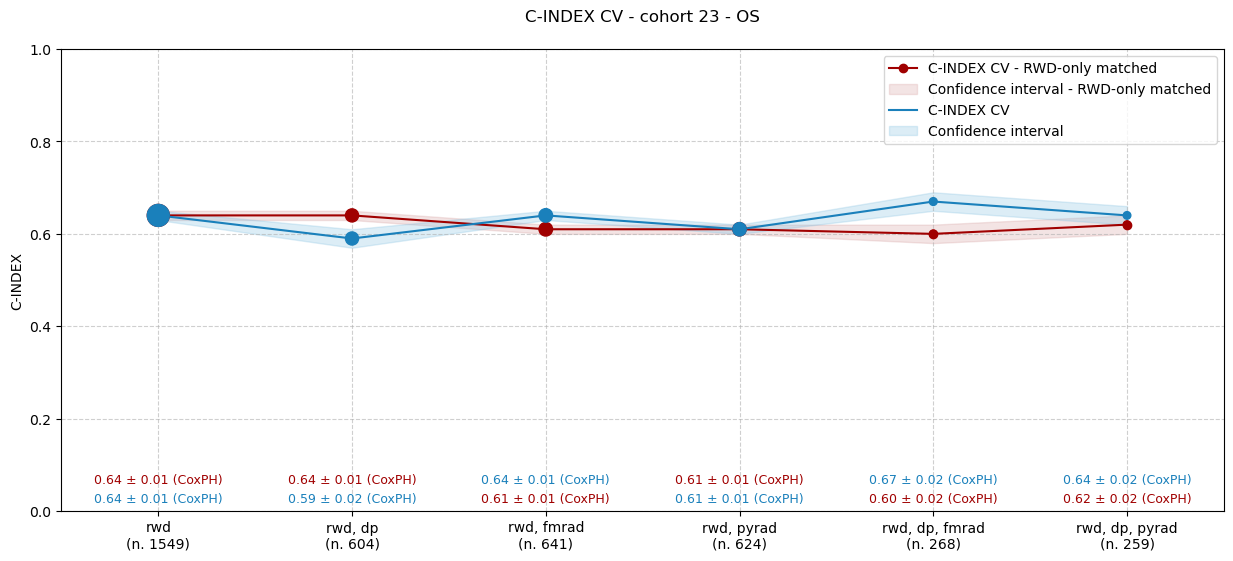

In [68]:
plot_best_cindex_by_modality_with_pvalues_survival(
    data="results_survival.xlsx",
    cohort=23,
    subset_int=False,
    features_required="UOC_FEATURES",
    only_blue=False,
    sites=sites,
    show=True
)

# DLIF MAIN ANALYSIS TEST

# TEST

In [ ]:
import os
import pickle
from pathlib import Path
from typing import Iterable, Optional, Union, List, Tuple, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from Delong_test import delong_roc_variance, compute_ground_truth_statistics, fastDeLong_no_weights

def delong_test_comparison(y_true, y_pred1, y_pred2, alpha=0.05):
    """
    Compare two ROC curves using DeLong's test for statistical significance.
    
    Args:
        y_true: True binary labels
        y_pred1: Predictions from first model (
        y_pred2: Predictions from second model 
        alpha: Significance level (default 0.05)
    
    Returns:
        p-value
    """
    # Compute AUC and variance for each model
    auc1, var1 = delong_roc_variance(y_true, y_pred1)
    auc2, var2 = delong_roc_variance(y_true, y_pred2)
    
    # Compute covariance between the two AUCs
    # For this we need to combine predictions and compute joint variance
    predictions_combined = np.array([y_pred1, y_pred2])
    order, label_1_count = compute_ground_truth_statistics(y_true)
    predictions_sorted_transposed = predictions_combined[:, order]
    aucs, cov_matrix = fastDeLong_no_weights(predictions_sorted_transposed, label_1_count)
    
    # Extract covariance
    cov_12 = cov_matrix[0, 1] if cov_matrix.ndim > 1 else 0
    
    # Compute test statistic
    auc_diff = auc1 - auc2
    var_diff = var1 + var2 - 2 * cov_12
    
    if var_diff <= 0:
        var_diff = 1e-10  # Avoid division by zero
    
    z_score = auc_diff / np.sqrt(var_diff)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # Two-tailed test
    

    return p_value

def p_to_stars(p: float) -> str:
    """Converts a p-value to a significance star string."""
    if p <= 0.0001: return '****'
    if p <= 0.001: return '***'
    if p <= 0.01: return '**'
    if p <= 0.05: return '*'
    return 'ns'

def plot_auc_from_folder(
    root: Union[str, Path],
    architecture: Literal["MLEF", "DLIF"],
    analyses: Union[str, Iterable[str]],                       # e.g. "C23" or ["C23", "C45"]
    *,
    modality_order: Optional[List[str]] = None,                # enforce x-axis order
    exclude_modalities: Iterable[str] = ("DP", "FMRAD", "PYRAD"),
    title_prefix: Optional[str] = None,
    min_bubble: float = 30,
    max_bubble: float = 250,
    show: bool = True,
    save_dir: Optional[Union[str, Path]] = None
):
    """
    Expected per-analysis layout (e.g. 'C23'):
      root/
        MLEF/ (or DLIF/)
          C23/
            RWD/
              model_XX.pkl
              train_set.xlsx
              test_set.xlsx
              prediction_CV.xlsx   (columns: Subject, y_pred, y_true)
              results.xlsx      (metrics incl. CV AUC)
            RWD_DP/
               RWD_ONLY/         (MLEF only)
            RWD_PYRAD/
            RWD_FMRAD/
            RWD_DP_PYRAD/
            RWD_DP_FMRAD/
    """

    # ------------------------- utilities -------------------------
    def _parse_mean_std(val) -> Tuple[float, float]:
        if pd.isna(val):
            return (np.nan, np.nan)
        if isinstance(val, (int, float, np.floating)):
            return (float(val), 0.0)
        s = str(val).replace("+/-", "±")
        parts = [p.strip() for p in s.split("±")]
        try:
            if len(parts) == 2:
                return (float(parts[0]), float(parts[1]))
            return (float(parts[0]), 0.0)
        except Exception:
            return (np.nan, np.nan)

    def _read_auc_cv(results_path: Path) -> Tuple[float, float]:
        if results_path is None or not results_path.exists():
            return (np.nan, np.nan)
        df = pd.read_excel(results_path)
        # 1) direct 'CV AUC'
        for col in df.columns:
            if str(col).strip().upper() in ("CV AUC", "CV_AUC", "AUC_CV", "AUC_cv"):
                return _parse_mean_std(df[col].iloc[0])
        # 2) SET + AUC with a 'CV' row
        set_cols = [c for c in df.columns if str(c).strip().upper() in ("SET", "SPLIT", "PHASE")]
        auc_cols = [c for c in df.columns if str(c).strip().upper() == "AUC"]
        if set_cols and auc_cols:
            sub = df.copy()
            mask = False
            for sc in set_cols:
                mask = mask | (sub[sc].astype(str).str.upper().str.contains("CV"))
            sub = sub[mask]
            if not sub.empty:
                return _parse_mean_std(sub[auc_cols[0]].iloc[0])
        # 3) any 'AUC' column at first row
        if auc_cols:
            return _parse_mean_std(df[auc_cols[0]].iloc[0])
        return (np.nan, np.nan)

    def _read_model_name(model_path: Path) -> str:
        """
        Model files are named like 'model_LR' or 'model_RF'.
        Return the substring after the first underscore.
        """
        if model_path is None or not model_path.exists():
            return "UnknownModel"
        stem = model_path.name  # allow filenames without extensions
        # If it has an extension, strip it
        if "." in stem:
            stem = stem.split(".", 1)[0]
        if "_" in stem:
            return stem.split("_", 1)[1] or "UnknownModel"
        return "UnknownModel"

    def _read_n_train(train_path: Path) -> int:
        if train_path is None or not train_path.exists():
            return int(np.nan)
        try:
            return int(pd.read_excel(train_path).shape[0])
        except Exception:
            return int(np.nan)

    def _scale_sizes(raw_sizes: Iterable[Union[int, float]]) -> np.ndarray:
        arr = np.array(list(raw_sizes), dtype=float)
        if arr.size == 0 or np.all(np.isnan(arr)):
            return np.array([])
        amin, amax = np.nanmin(arr), np.nanmax(arr)
        if not np.isfinite(amin) or not np.isfinite(amax) or (amax - amin < 1e-9):
            return np.full_like(arr, (min_bubble + max_bubble) / 2.0)
        norm = (arr - amin) / (amax - amin + 1e-6)
        return norm * (max_bubble - min_bubble) + min_bubble

    def _ordered_modalities(mods: List[str]) -> List[str]:
        filtered = [m for m in mods if m not in exclude_modalities]
        if modality_order:
            in_order = [m for m in modality_order if m in filtered]
            leftovers = [m for m in filtered if m not in in_order]
            return in_order + leftovers
        return filtered

    def _collect_modalities(analysis_dir: Path) -> List[str]:
        return _ordered_modalities([p.name for p in analysis_dir.iterdir()
                                    if p.is_dir() and p.name.upper().startswith("RWD")])

    def _pair_paths(analysis_dir: Path, modality: str):
        """
        Robust path resolver:
        - accepts RWD_ONLY or rwd-only (any case)
        - accepts files named like results(.xlsx/.xls), prediction(_CV)?.xlsx, train_set(.xlsx), etc.
        - accepts files with different case
        """
        def find_first(dir_: Path, stems: List[str]) -> Optional[Path]:
            if not dir_.exists():
                return None
            # try exact matches first
            for st in stems:
                for ext in ("", ".xlsx", ".xls"):
                    p = dir_ / f"{st}{ext}"
                    if p.exists():
                        return p
            # then glob by prefix (case-insensitive)
            cand: List[Path] = []
            for st in stems:
                cand += list(dir_.glob(f"{st}*"))
                cand += list(dir_.glob(f"{st.upper()}*"))
                cand += list(dir_.glob(f"{st.lower()}*"))
            # prefer xlsx/xls if multiple
            cand = sorted(cand, key=lambda x: (x.suffix.lower() not in {".xlsx", ".xls"}, len(x.name)))
            return cand[0] if cand else None

        def find_subdir_any(dir_: Path, names: List[str]) -> Optional[Path]:
            if not dir_.exists():
                return None
            # exact
            for n in names:
                p = dir_ / n
                if p.exists() and p.is_dir():
                    return p
            # case-insensitive scan
            low_targets = {n.lower(): n for n in names}
            for p in dir_.iterdir():
                if p.is_dir() and p.name.lower() in low_targets:
                    return p
            return None

        mod_dir = analysis_dir / modality

        paths = {
            "mod": {
                "results": find_first(mod_dir, ["results", "Results"]),
                "pred":    find_first(mod_dir, ["prediction_CV", "prediction", "Prediction"]),
                "model":   find_first(mod_dir, ["model_", "model"]),   # picks model_LR / model_RF
                "train":   find_first(mod_dir, ["train_set", "Train_set", "train"]),
            },
            "rwd_only": None
        }

        if architecture == "MLEF":
            ro_dir = find_subdir_any(
                mod_dir,
                ["RWD_ONLY", "rwd-only", "Rwd_only", "RWD-ONLY"]
            )
            if ro_dir:
                paths["rwd_only"] = {
                    "results": find_first(ro_dir, ["results", "Results"]),
                    "pred":    find_first(ro_dir, ["prediction_CV", "prediction", "Prediction"]),
                    "model":   find_first(ro_dir, ["model_", "model"]),
                    "train":   find_first(ro_dir, ["train_set", "Train_set", "train"]),
                }
        return paths


    def _compute_pvalue(pred_mod_path: Path, pred_ro_path: Path) -> Optional[float]:
        """
        Read predictions directly from prediction.xlsx files (Subject, y_pred, y_true),
        align on Subject, then run DeLong.
        """
        if not (pred_mod_path and pred_ro_path and pred_mod_path.exists() and pred_ro_path.exists()):
            return None
        dm = pd.read_excel(pred_mod_path)
        dr = pd.read_excel(pred_ro_path)
        # minimal schema check
        for col in ("Subject", "y_pred", "y_true"):
            if col not in dm.columns:
                return None
        if "Subject" not in dr.columns or "y_pred" not in dr.columns:
            return None

        m = dm.rename(columns={"y_pred": "y_pred_mod"})
        r = dr.rename(columns={"y_pred": "y_pred_ro"})
        merged = pd.merge(m[["Subject", "y_true", "y_pred_mod"]],
                          r[["Subject", "y_pred_ro"]],
                          on="Subject", how="inner")
        if merged.empty:
            return None
        return float(delong_test_comparison(
            merged["y_true"].to_numpy(),
            merged["y_pred_mod"].to_numpy(),
            merged["y_pred_ro"].to_numpy()
        ))

    def _plot_one(analysis: str, rows: List[dict]) -> plt.Figure:
        modalities = [r["modality"] for r in rows]
        X = np.arange(len(modalities))

        auc_mod_mean = np.array([r["auc_mod_mean"] for r in rows], dtype=float)
        auc_mod_std  = np.array([r["auc_mod_std"]  for r in rows], dtype=float)
        n_train_mod  = np.array([r["n_train_mod"]  for r in rows], dtype=float)
        sizes        = _scale_sizes(n_train_mod)
        model_names  = [r["model_mod"] for r in rows]

        fig = plt.figure(figsize=(12, 6))
        # BLUE: modality
        plt.plot(X, auc_mod_mean, linestyle="-", marker="o", label="CV AUC", color="#1a80bb")
        plt.scatter(X, auc_mod_mean, s=sizes, color="#1a80bb", zorder=3)
        plt.fill_between(X, auc_mod_mean - auc_mod_std, auc_mod_mean + auc_mod_std,
                         alpha=0.3, color="#8cc5e3", label="Confidence interval")

        multimodal_better = None

        if architecture == "MLEF":
            auc_ro_mean = np.array([r["auc_ro_mean"] for r in rows], dtype=float)
            auc_ro_std  = np.array([r["auc_ro_std"]  for r in rows], dtype=float)
            plt.plot(X, auc_ro_mean, linestyle="-", marker="o", label="CV AUC - RWD-only matched", color="#a00000")
            plt.scatter(X, auc_ro_mean, s=sizes, color="#a00000", zorder=3)
            plt.fill_between(X, auc_ro_mean - auc_ro_std, auc_ro_mean + auc_ro_std,
                             alpha=0.3, color="#d8a6a6", label="Confidence interval - RWD-only matched")
            multimodal_better = (auc_mod_mean > auc_ro_mean)

        xticks = [f"{m}\n(n. {int(n) if np.isfinite(n) else 'NA'})" for m, n in zip(modalities, n_train_mod)]
        plt.xticks(X, xticks)

        # --- BLUE annotations (now show stars here) ---
        for i, (mval, mstd, mname) in enumerate(zip(auc_mod_mean, auc_mod_std, model_names)):
            base_y = 0.06 if (multimodal_better is not None and multimodal_better[i]) else 0.02
            plt.text(i, base_y, f"{mval:.2f} ± {mstd:.2f} ({mname})",
                    fontsize=9, ha="center", color="#1a80bb")
            # stars belong to the multimodal-vs-RWD comparison
            star = rows[i].get("stars", "")
            if star:
                # nudge a bit to the right of the blue text
                plt.text(i + 0.33, base_y + 0.006, star, fontsize=10, ha="left", va="center", color="black")


        # --- RED annotations (keep values but REMOVE stars here) ---
        if architecture == "MLEF":
            for i, rrow in enumerate(rows):
                rv, rs, rname = rrow["auc_ro_mean"], rrow["auc_ro_std"], rrow["model_ro"]
                base_y = 0.02 if multimodal_better[i] else 0.06
                if np.isfinite(rv) and np.isfinite(rs):
                    plt.text(i, base_y, f"{rv:.2f} ± {rs:.2f} ({rname})",
                            fontsize=9, ha="center", color="#a00000")

        ttl = title_prefix or f"CV AUC - {architecture}"
        plt.title(f"{ttl} - {analysis}", pad=18)
        plt.ylabel("AUC")
        plt.ylim(0, 1)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.xlim(-0.4, len(modalities) - 0.55)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            out = Path(save_dir) / f"{ttl.replace(' ', '_')}_{analysis}.png"
            plt.savefig(out, dpi=600, bbox_inches="tight")
        if show:
            plt.show()
        return fig

    # ------------------------- main logic -------------------------
    root = Path(root)
    if isinstance(analyses, str):
        analyses = [analyses]

    for analysis in analyses:
        analysis_dir = root / architecture / analysis
        if not analysis_dir.exists():
            continue

        modalities = _collect_modalities(analysis_dir)
        if not modalities:
            continue

        rows: List[dict] = []
        for mod in modalities:
            paths = _pair_paths(analysis_dir, mod)
            # modality side
            auc_m, std_m = _read_auc_cv(paths["mod"]["results"])
            model_m = _read_model_name(paths["mod"]["model"])
            ntrain_m = _read_n_train(paths["mod"]["train"])

            row = {
                "modality": mod,
                "auc_mod_mean": float(auc_m),
                "auc_mod_std": float(std_m) if np.isfinite(std_m) else 0.0,
                "n_train_mod": ntrain_m,
                "model_mod": model_m,
            }

            # paired RWD_ONLY (MLEF only) with RWD red==blue behavior
            if architecture == "MLEF":
                if mod == "RWD":
                    # enforce coincidence for RWD: red == blue; no p-value
                    row.update({
                        "auc_ro_mean": row["auc_mod_mean"],
                        "auc_ro_std":  row["auc_mod_std"],
                        "n_train_ro":  row["n_train_mod"],
                        "model_ro":    row["model_mod"],
                        "pvalue":      None,
                        "stars":       ""
                    })
                else:
                    ro = paths["rwd_only"]
                    if ro is not None:
                        auc_r, std_r = _read_auc_cv(ro["results"])
                        pval = _compute_pvalue(paths["mod"]["pred"], ro["pred"])
                        row.update({
                            "auc_ro_mean": float(auc_r),
                            "auc_ro_std":  float(std_r) if np.isfinite(std_r) else 0.0,
                            "n_train_ro":  _read_n_train(ro["train"]),
                            "model_ro":    _read_model_name(ro["model"]),
                            "pvalue":      pval,
                            "stars":       p_to_stars(pval) if (pval is not None and np.isfinite(pval)) else ""
                        })
                    else:
                        row.update({
                            "auc_ro_mean": np.nan,
                            "auc_ro_std":  np.nan,
                            "n_train_ro":  np.nan,
                            "model_ro":    "NA",
                            "pvalue":      None,
                            "stars":       ""
                        })

            rows.append(row)

        rows = [r for r in rows if np.isfinite(r["auc_mod_mean"])]
        if not rows:
            continue

        _ = _plot_one(analysis, rows)


Processing C23 - RWD
  Modality paths: {'mod': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/results.xlsx'), 'pred': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/prediction_CV.xlsx'), 'model': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/model_RF.pkl'), 'train': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/train_set.xlsx')}, 'rwd_only': None}
Processing C23 - RWD_DP
  Modality paths: {'mod': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/results.xlsx'), 'pred': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/prediction_CV.xlsx'), 'model': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/model_LR.pkl'), 'train': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/train_set.xlsx')}, 'rwd_only': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/rwd-only/results.xlsx'), 'pred

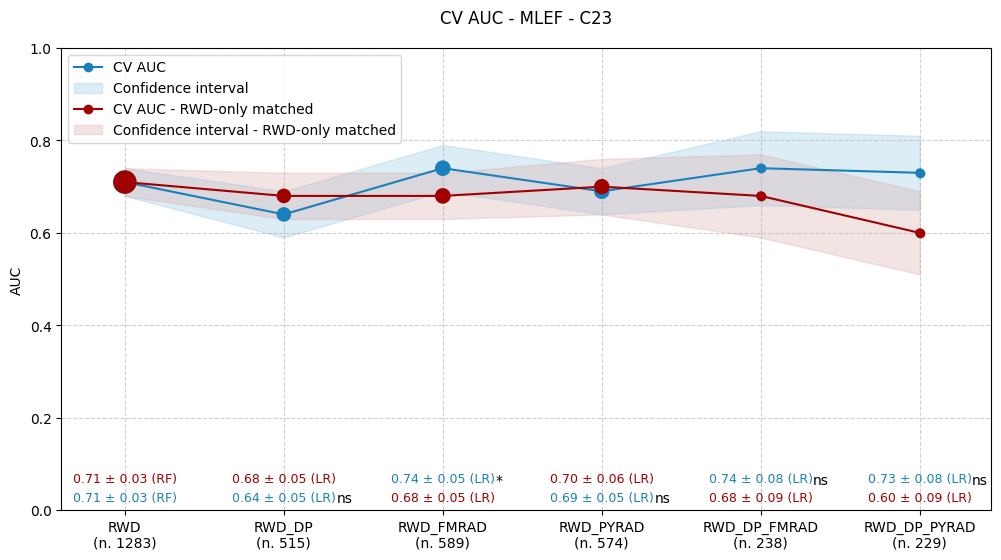

In [18]:
plot_auc_from_folder(
    root=r'c:\\Users\\Cristina\\AI-ON lab\\I3LUNG_PDSS',
    architecture="MLEF",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

In [20]:
r_pred = pd.read_excel('MLEF/C23/RWD_DP_PYRAD/rwd-only/prediction_CV.xlsx')
m_pred = pd.read_excel('MLEF/C23/RWD_DP_PYRAD/prediction_CV.xlsx')
print(delong_test_comparison(
            m_pred['y_true'].to_numpy(),
            m_pred["y_pred"].to_numpy(),
            r_pred["y_pred"].to_numpy()))

0.2093922832766828


In [23]:
import joblib
m_model = joblib.load('MLEF/C23/RWD_DP_PYRAD/model_LR.pkl')
m_train = pd.read_excel('MLEF/C23/RWD_DP_PYRAD/train_set.xlsx')
r_model = joblib.load('MLEF/C23/RWD_DP_PYRAD/rwd-only/model_LR.pkl')
r_train = pd.read_excel('MLEF/C23/RWD_DP_PYRAD/rwd-only/train_set.xlsx')

In [29]:
from sklearn.utils import compute_sample_weight
from sklearn.model_selection import GroupKFold
features = m_model.feature_names_in_
folds = m_train['FOLD']
X = m_train[features]
y_true = m_train['OS_MONTHS']

y_pred_m = pd.Series(index=m_train.index, dtype=float)

cv = GroupKFold(n_splits=len(folds.unique()))
def cv_getter():
    return cv.split(X, y_true, groups=folds)

for train_idx, test_idx in cv_getter():
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_true.iloc[train_idx])
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y_true.iloc[train_idx], y_true.iloc[test_idx]
    m_model.fit(X_tr, y_tr, sample_weight=sample_weight)
    y_pred_m.iloc[test_idx] = m_model.predict_proba(X_te)[:, 1]



In [32]:
features = r_model.feature_names_in_
folds = r_train['FOLD']
X = r_train[features]
y_true = r_train['OS_MONTHS']

y_pred_r = pd.Series(index=r_train.index, dtype=float)

cv = GroupKFold(n_splits=len(folds.unique()))
def cv_getter():
    return cv.split(X, y_true, groups=folds)

for train_idx, test_idx in cv_getter():
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_true.iloc[train_idx])
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y_true.iloc[train_idx], y_true.iloc[test_idx]
    r_model.fit(X_tr, y_tr, sample_weight=sample_weight)
    y_pred_r.iloc[test_idx] = r_model.predict_proba(X_te)[:, 1]

In [33]:
print(delong_test_comparison(
            m_pred['y_true'].to_numpy(),
            y_pred_m.to_numpy(),
            y_pred_r.to_numpy()))

0.002296519831074484
